Every morning, Quan King unlocks the doors of Christy Recreation Center in West Philadelphia and hopes the overnight count is zero. King, who runs the rec center and has experienced gun violence trauma alongside the children in his neighborhood, knows the dangers that Philadelphia youth may face.

## *"We lost four kids this summer to gun violence,*
## *That's the trauma that a lot of our youth are dealing with right now. They're trying to figure out how to cope and best move forward."*

King's rec center is one small pocket in a city that has been grappling, for years, with a crisis hiding in plain sight: one that shows up in police data, in emergency room visits, and in the quiet behavioral shifts of children who have learned to read danger before they have learned to drive. Gun violence in Philadelphia stretches far beyond just a public safety problem. And for the city's youngest residents, the damage runs far deeper than what any shooting victim database can record.

<img src="quanking.png" width="800">

Gun violence is the leading cause of death for children and teenagers in the United States, surpassing car accidents in 2020 and holding that grim distinction every year since. According to the CDC, 32 children and teens are injured by gunfire every single day in America, and seven are killed. In Philadelphia, those national numbers find their sharpest expression: according to Chalkbeat Philadelphia, there were 450 to 500 total shootings annually between 2020 and 2022. Though the numbers have dropped significantly since, thousands of kids are still grappling with firsthand loss or the ongoing risk of gun violence in their communities. Research from Penn's Leonard Davis Institute deepens the picture further: roughly one in eight Black adolescent males in Philadelphia will be shot or killed before their 25th birthday.

The city's shooting victim data, maintained by the Philadelphia Police Department and published through OpenDataPhilly, makes those stakes visible at scale. Every recorded shooting victim since 2015 is in this dataset. Victims between 18 and 34 account for the largest share, but the bar representing children under 18 is not a small one. Over 1,500 minors appear in the record. And the racial breakdown is stark: roughly 80% of all shooting victims in Philadelphia are Black, a proportion that mirrors the same geographic concentration of poverty and disinvestment that Penn's research describes.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

import warnings
warnings.simplefilter('ignore')

In [13]:
shoot_df = pd.read_csv('data/shootings.csv') 
youth_df = shoot_df[shoot_df['age'] < 18]

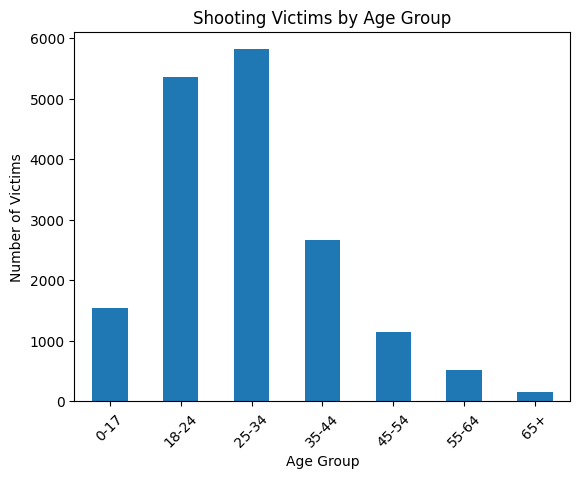

In [21]:
bins = [0, 17, 24, 34, 44, 54, 64, 100]
labels = ['0-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

shoot_df['age_group'] = pd.cut(shoot_df['age'], bins=bins, labels=labels)

age_counts = shoot_df['age_group'].value_counts().sort_index()

plt.figure()
age_counts.plot(kind='bar')
plt.title("Shooting Victims by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Victims")
plt.xticks(rotation=45)
plt.show()

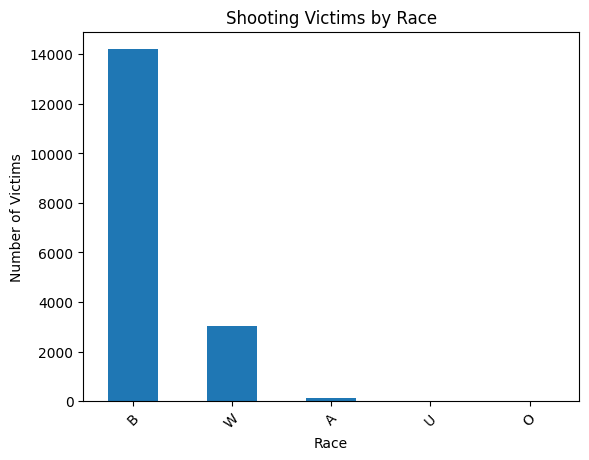

In [22]:
race_counts = shoot_df['race'].value_counts()

plt.figure()
race_counts.plot(kind='bar')
plt.title("Shooting Victims by Race")
plt.xlabel("Race")
plt.ylabel("Number of Victims")
plt.xticks(rotation=45)
plt.show()

But what these charts cannot show is what happens to the children after experiencing gun violence. Because the research is now unambiguous: gun violence does not require a fatal bullet to cause lasting harm.

## Beyond Physical Injury: The Mental Health Impact

A 2025 study published in Nature Mental Health, analyzing a national sample of U.S. adults, found that between 58% and 94% of people exposed to gun violence (as direct victims, bystanders, or community witnesses) reported significant mental health consequences. Those consequences included heightened anxiety, depression, PTSD, and elevated rates of suicidal ideation. Critically, the study found that younger people were among the most vulnerable, and that indirect exposure-- hearing a gunshot, witnessing its aftermath, living in a neighborhood where it repeatedly occurs-- produced outcomes nearly as severe as direct victimization.

For Philadelphia youth, that proximity is both occasional and structural. Research on community violence exposure documents what clinicians call "anticipatory stress": the constant cognitive and physiological toll of scanning for danger. Strikingly, researchers with the Perelman School of Medicine at Penn and Children's Hospital of Philadelphia found that children who live close to areas where shootings occurred are 134% more likely to visit the emergency room for a mental health issue. 

Using the Gun Violence Archive, The Trace analyzed shootings within 500 feet of schools nationwide from 2014 through 2023 and found that five of the top ten schools most exposed to nearby gunfire were in the School District of Philadelphia, all of them in Kensington. A student named Katoura, quoted in that reporting, described her vigilance in a tutoring class: "Sometimes, when I'm in my tutoring class I hear gunshots going off, and I'm the closest one to the window because that's where I sit. They tell us to get down, but that's when all we hear is screaming and yelling. That happens pretty often." For many Philadelphia teens, vigilance is a deeply-rooted trauma response. And for Philadelphia children, it disrupts the developmental work that adolescence is supposed to accomplish: building identity, forming relationships, imagining a future.

<img src="secondphoto.png" width="800">

## The Uneven Geography of Gun Violence

Part of what makes this mental health crisis so difficult to treat is that it has no single address. In Philadelphia, the data shows that 93.8% of youth shootings occur outdoors: on sidewalks, in parks, in the spaces between school and home that children are supposed to move through freely.

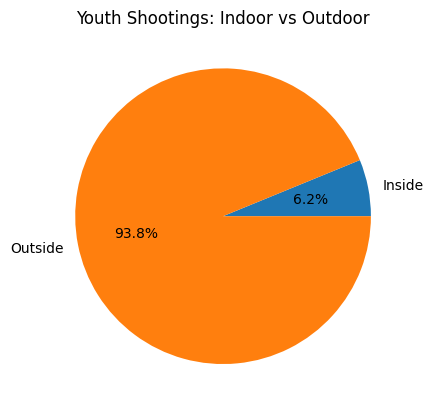

In [16]:
inside_outside = youth_df[['inside', 'outside']].apply(pd.to_numeric, errors='coerce').sum()

plt.figure()
plt.pie(inside_outside, labels=['Inside', 'Outside'], autopct='%1.1f%%')
plt.title("Youth Shootings: Indoor vs Outdoor")
plt.show()

That 93.8% describes the potential risk a child in could face in Philadelphia neighborhoods that face larger rates of gun violence. Unlike a domestic incident, outdoor community violence has no clear perimeter. You cannot avoid it by avoiding a specific place. For Philadelphia youth, it can be a walk to the corner store, or a bus stop, or even on the way home.

Researchers studying community violence exposure have found that this ambient, locationless quality is precisely what makes gun violence so psychologically corrosive. There is no safe internal narrative available. No "as long as I stay away from X, I'll be fine." Terry Jr., a young adult participating in the Wealth and Work Futures Lab at Drexel University, a digital program focused on grief and gun violence among young people from high-violence neighborhoods, put it this way: "I didn't know how to engage with other people. It was just like, 'this happens, and it's been happening since I was a kid.' So it wasn't something that I found to be strange or something that I thought was going to impact me." The normalization of violence is itself a psychological injury, one that often goes unrecognized because it doesn't announce itself as trauma.

A Trace analysis of shooting data reinforces the permanence of this geographic burden: "The neighborhoods that were the most affected in 2015 are still experiencing the most bloodshed a decade later. In Upper Kensington, shootings dropped dramatically. But the neighborhood had the most shootings in 2024; the ranking remained consistent over the last 10 years." Even when raw numbers fall, the same communities bear the weight. And the children growing up in those communities absorb that weight regardless of what the citywide trend line is doing.

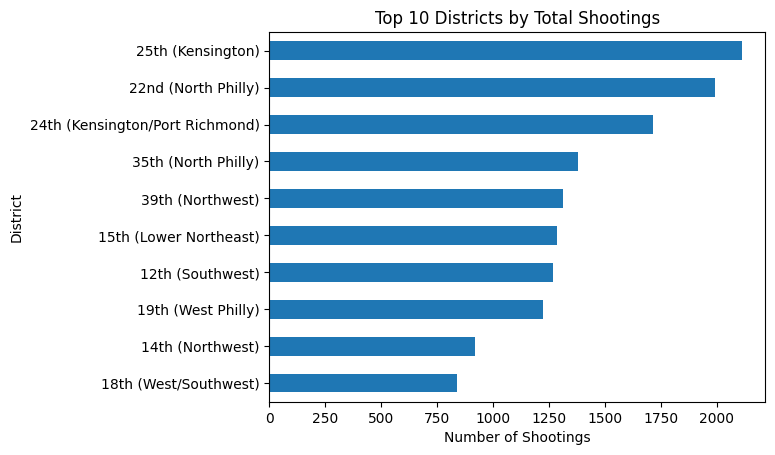

In [19]:
plt.figure()
district_counts.plot(kind='barh')

plt.title("Top 10 Districts by Total Shootings")
plt.xlabel("Number of Shootings")
plt.ylabel("District")

plt.gca().invert_yaxis()
plt.show()

## Zooming Out: The Broader Philadelphia Picture

To understand how entrenched this is, consider what the year-over-year data actually shows. Philadelphia shooting incidents peaked at over 2,200 in 2021, the city's most violent year in recent memory, before beginning a sustained decline. By 2024, homicides had fallen nearly 37% compared to the prior year, the largest single-year drop among any major American city. By the close of 2025, Philadelphia recorded 222 homicides, the fewest since 1966.

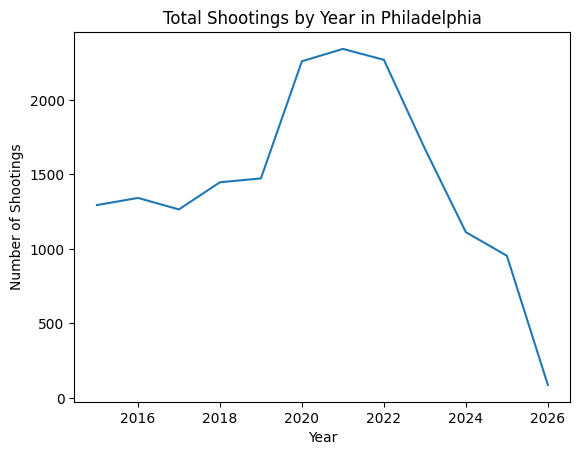

In [3]:
yearly_trend = shoot_df.groupby('year').size()

plt.figure()
plt.plot(yearly_trend.index, yearly_trend.values)
plt.title("Total Shootings by Year in Philadelphia")
plt.xlabel("Year")
plt.ylabel("Number of Shootings")
plt.show()

In [4]:
district_labels = {
    '1': '1st (South Philly)',
    '2': '2nd (Northeast)',
    '3': '3rd (West Philly)',
    '5': '5th (North Philly)',
    '6': '6th (Center City)',
    '7': '7th (Northeast)',
    '8': '8th (Northeast)',
    '9': '9th (Center City)',
    '12': '12th (Southwest)',
    '14': '14th (Northwest)',
    '15': '15th (Lower Northeast)',
    '16': '16th (West Philly)',
    '17': '17th (South Philly)',
    '18': '18th (West/Southwest)',
    '19': '19th (West Philly)',
    '22': '22nd (North Philly)',
    '24': '24th (Kensington/Port Richmond)',
    '25': '25th (Kensington)',
    '26': '26th (River Wards)',
    '35': '35th (North Philly)',
    '39': '39th (Northwest)'
}

<Figure size 640x480 with 0 Axes>

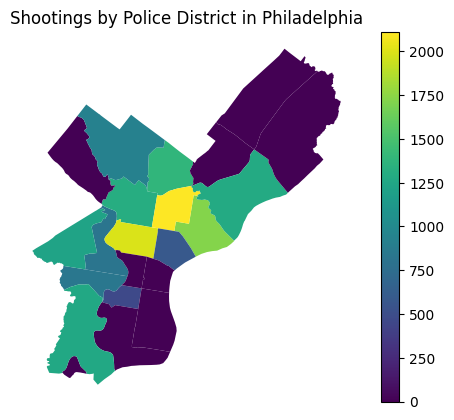

In [6]:
shoot_df['dist'] = shoot_df['dist'].astype(str).str.replace('.0', '', regex=False)
district_counts = shoot_df.groupby('dist').size().reset_index(name='shootings')

gdf = gpd.read_file("Boundaries_District.geojson")
gdf['DIST_NUMC'] = gdf['DIST_NUMC'].astype(str)
gdf = gdf.merge(district_counts, left_on='DIST_NUMC', right_on='dist', how='left')
gdf['shootings'] = gdf['shootings'].fillna(0)

plt.figure()
gdf.plot(column='shootings', legend=True)

plt.title("Shootings by Police District in Philadelphia")
plt.axis('off')
plt.show()

That trend line is real, and it matters. But the map of Philadelphia above tells the quieter truth: even as the aggregate number falls, the concentration has not moved. Kensington and North Philadelphia remain the brightest spots on the map. Progress at the citywide level does not automatically reach the streets where children are growing up.

What's driving the decline is a mix of strategies that researchers are still working to disentangle. Philadelphia simultaneously increased police presence in high-violence areas, expanded community violence intervention programs, improved homicide clearance rates, and directed $28 million to grassroots anti-violence organizations. Mayor Parker's current budget includes $25 million for community-based anti-violence programs, 200 community police officers, and a $95 million reserve fund to cover potential losses in federal funding. These are meaningful investments. But the scale of the mental health fallout, built up over a decade of peak violence, means that preventing new shootings and healing the damage from past ones are two entirely different projects, requiring two entirely different kinds of sustained commitment.

<img src="thirdphoto.png" width="800">

## What Comes Next

The mental health dimension of this crisis has long received less attention and fewer resources than violence prevention, even though the two are closely linked. Research consistently shows that untreated trauma in childhood does not simply fade over time. Over time, it shapes how young people process stress, make decisions, and respond to risk, ultimately influencing school performance, relationships, and long-term stability, often reinforcing the very conditions that violence prevention efforts are trying to disrupt.

Programs like NAMI Philadelphia and Healing Hurt People have built important models to address this gap, offering therapy, peer support, and intervention in the immediate aftermath of violence exposure. Their work recognizes that recovery has to begin early and within the community. At the same time, their reach remains limited compared to the scale of need. For many young people, access to consistent, trauma-informed care is still the exception rather than the norm.

The city’s recent decline in gun violence is meaningful: it shows that sustained investment and targeted strategies can reduce harm. But lower numbers do not erase what has already been experienced. The young people who came of age during the years when shootings exceeded 2,000 annually are still living with the effects of that environment. Exposure to violence leaves marks that do not appear in crime statistics but continue to shape daily life, from how safe someone feels walking outside to how they concentrate in a classroom.

If the goal is not only to reduce violence but to change long-term outcomes, then the response has to extend beyond prevention alone. It requires treating mental health support as a core part of public safety. That means investing at a scale that matches the problem, integrating care into schools and neighborhoods, and recognizing that recovery is not immediate or easily measured. Progress is not only reflected in fewer shootings, but in whether the young people most affected are given a real chance to heal and move forward.